<a href="https://colab.research.google.com/github/kabirmuwal/Academic-Projects/blob/main/Netflix_Media_and_Expansion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Defining a Business (NETFLIX Media and Expansion)**

*Netflix is the globally known app which was launched and discovered in United States in 2010 and has evolved over the years as an excellent streaming platform for users across the globe (as of 2022, excluding countries: China, North Korea , Russia and Syria).This Tabular data set show cases the list of movies around the world and TV shows that can be watched on Netflix - elaborating about casts, directors, ratings, release date, duration, and so on.*

*Our Goal is to find out best recommendations on Netflix from the data provided to have more viewers for the company.*

**Reference for the Data Set:** https://www.kaggle.com/code/shivamb/netflix-shows-and-movies-exploratory-analysis

**IMPORTANT LIBRARIES**

In [ ]:
import seaborn as sebon
import pandas as pndas
import folium
import branca.colormap as cmp
import matplotlib.pyplot as mtplib
from folium.plugins import HeatMap
import numpy as nupy

**Rest of the Libraries I have used when they were required in the process**

## **UPLOADING AND CLEANING THE GIVEN DATASET**

Overview of the Dataset:

1.   **Show ID:** comprises of how many shows/seasons or parts of movie is it
2.   **Type:** Is it a movie or a tv show?
3.   **Title:** Name of the respective movie or show
4.   **Director:** Corresponds to who has made the movie or tv show
5.   **Cast:** Which celebrities can you see in the respective show or movie
6.   **Country:** In which country was the movie made
7.   **Date Added:** On which exact date was the movie/show available to watch on Netflix
8.   **Release year:** When was the movie/show actually realeased
9.   **Rating:** divided into codes which reflect weather the content is for kids  
or adults or how much it is graded by different measures by Imdb rating or so on
10.  **Duration:** actually duration of the movie/ show in minutes
11.  **Listed in:** type of movie/show is it documentary , comedy , action , ....
12.  **Description:** A small introduction for the movie or show


**UPLOADING THE DATASET**

In [ ]:
# Current data set is from the refrence provided

df_net = pndas.read_csv('/content/netflix_titles[1].csv')
print (df_net.shape)
df_net.head()

(5837, 12)


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


**Checking if the Data is clean or not?**

In [ ]:
df_main = df_net.copy()

if df_main.isna().sum().sum() != 0:
  print("The DataSet doesn't seems clean")
else:
    print("The Dataset seems clean ")

The DataSet doesn't seems clean


**As the data is not clean 😩 we need to check how many NaN values are there 😖**

In [ ]:
df_main.isna().sum()

,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


**As observed the NAN values in the dataset is as follows:**

1.   Director : 2634
2.   Cast : 825
3.   Country : 835
4.   Date_added 10
5.   Rating : 4
6.   Duration : 3

So we will opt for different methods to clean the data set as we require the values in the columns and can't just simply remove all the columns.

*   *Firstly we reduce the unwanted columns (removing cast and description)*
*  *We will replace the Nan values in **'country column with others'
*  *We will use Unique values for " Rating and duration"*

In [ ]:
# removing columns with Nan values and are unwanted
to_drop = ['description', 'cast']

df_main.drop(to_drop, inplace=True, axis=1)

In [ ]:
# We will replace the Nan values in country column with others as it would be required for future instance
default_country = 'others'
df_main['country'] = df_main['country'].fillna(default_country)

In [ ]:
#Checking the unique values for Rating and Duration

df_main['rating'].unique()
df_main['duration'].unique()

array(['1 Season', '67 min', '135 min', '106 min', '2 Seasons', '107 min',
       '81 min', '118 min', '110 min', '104 min', '93 min', '94 min',
       '124 min', '137 min', '134 min', '69 min', '209 min', '86 min',
       '24 min', '46 min', '117 min', '87 min', '92 min', '114 min',
       '121 min', '109 min', '96 min', '97 min', '56 min', '119 min',
       '3 Seasons', '8 Seasons', '138 min', '111 min', '88 min', '73 min',
       '116 min', '85 min', '102 min', '101 min', '28 min', '103 min',
       '131 min', '166 min', '105 min', '82 min', '84 min', '112 min',
       '89 min', '136 min', '129 min', '158 min', '78 min', '100 min',
       '74 min', '60 min', '143 min', '98 min', '54 min', '59 min',
       '95 min', '5 Seasons', '61 min', '4 Seasons', '123 min', '44 min',
       '68 min', '99 min', '91 min', '40 min', '90 min', '108 min',
       '200 min', '133 min', '115 min', '55 min', '153 min', '185 min',
       '127 min', '120 min', '139 min', '122 min', '36 min', '141 min',
   

**Now let us identify how many string values or object values are there in the complete dataset.**

In [ ]:
# For checking the value count for each string or object variable in the data

for k in df_main.select_dtypes(include=['object']).columns:
  print (df_main[k].value_counts())
  print ('==='*15)

title
Tunnel                                           3
Love                                             3
Oh My Ghost                                      3
Limitless                                        3
The Silence                                      3
                                                ..
The Big Catch                                    1
The Bible's Buried Secrets                       1
Sword Art Online Alternative: Gun Gale Online    1
Sparta                                           1
To and From New York                             1
Name: count, Length: 5780, dtype: int64
director
Raúl Campos, Jan Suter    18
Marcus Raboy              14
Jay Karas                 13
Jay Chapman               12
Steven Spielberg           8
                          ..
Lenin Bharathi             1
James Foley                1
Kunihiko Yuyama            1
Ranjit Jeyakodi            1
Sorin Dan Mihalcescu       1
Name: count, Length: 3108, dtype: int64
country
United States    

In [ ]:
df_main.head()

,show_id,title,director,country,date_added,release_year,rating,duration,listed_in,type
0,81193313,Chocolate,NaN,South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",others,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",Movie
3,81082007,Atlantics,Mati Diop,"France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies",Movie
4,80213643,Chip and Potato,NaN,"Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,TV Show


In [ ]:
# We replace Nan values in rating with Good & Duration with Regular

df_main['date_added'] = df_main['date_added'].fillna(pndas.to_datetime('2024-01-01'))

default_rating = 'Unknown'
df_main['rating'] = df_main['rating'].fillna(default_rating)

default_duration = 'Not specified'
df_main['duration'] = df_main['duration'].fillna(default_duration)

unk_director = 'Unknown'
df_main['director'] = df_main['director'].fillna(unk_director)

**We see that the data seems Clean now so let's verify 🥳**

In [ ]:

if df_main.isna().sum().sum() != 0:
  print ("The DataSet doesn't seems clean")
else:
    print ("The Dataset seems clean ")


The Dataset seems clean 


In [ ]:
# Checking the spread of the  numeric data  with description for the dataset

df_main.describe()


,show_id,release_year
count,5.837000e+03,5837.000000
mean,7.730079e+07,2013.688539
std,9.479777e+06,8.419088
min,2.698800e+05,1925.000000
25%,8.004520e+07,2013.000000
50%,8.016353e+07,2016.000000
75%,8.024188e+07,2018.000000
max,8.122720e+07,2020.000000


In [ ]:
# Checking the spread of the object data  with description for the dataset

df_main.describe(include='object')

,title,director,country,date_added,rating,duration,listed_in,type
count,5837,5837,5837,5837,5837,5837,5837,5837
unique,5780,3109,528,1093,15,194,449,2
top,Tunnel,Unknown,United States,2024-01-01 00:00:00,TV-MA,1 Season,Documentaries,Movie
freq,3,1901,1907,642,1937,1259,297,3939


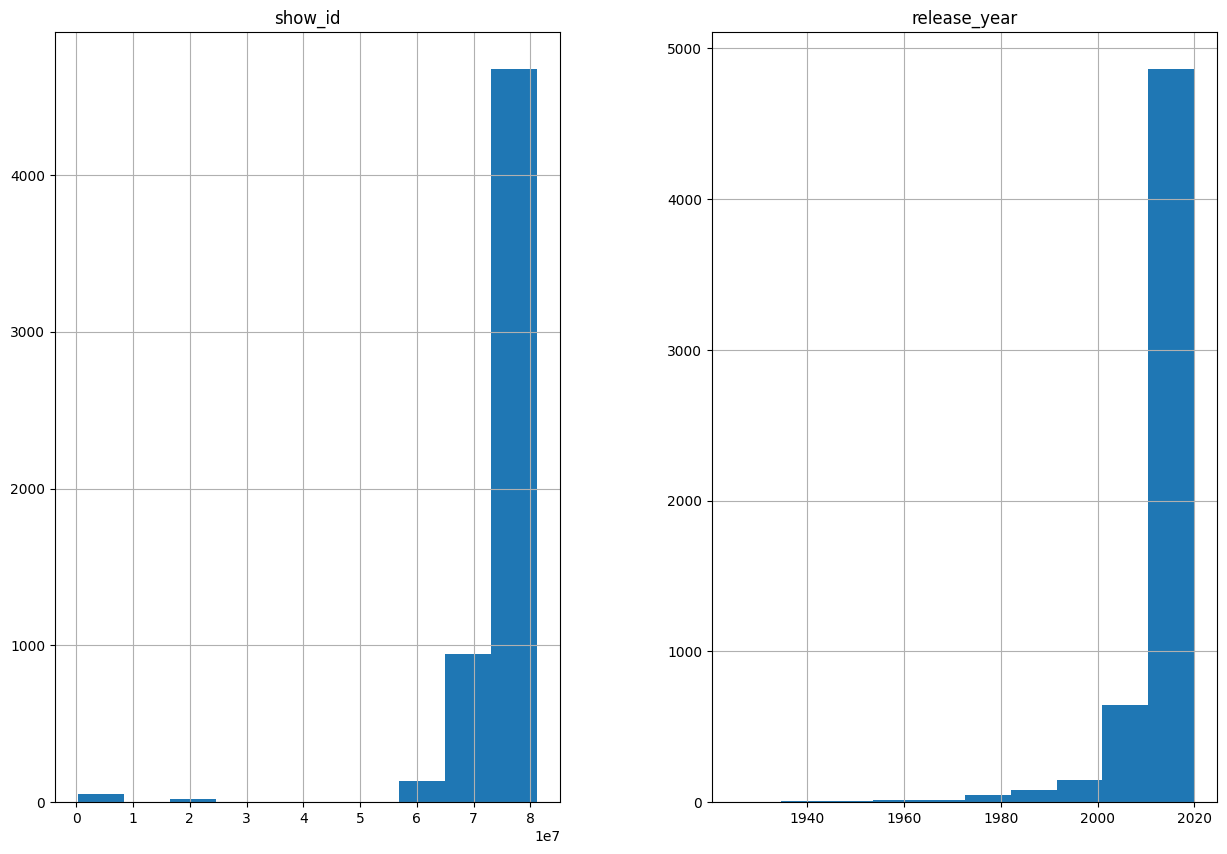

In [ ]:
# Checking the frequency and data distribution for the numeric variable

df_main.hist(figsize=(15,10))
mtplib.show()


### ***Business Questions***

**Question 1:** What is the most preferable Genre watched on Netflix?


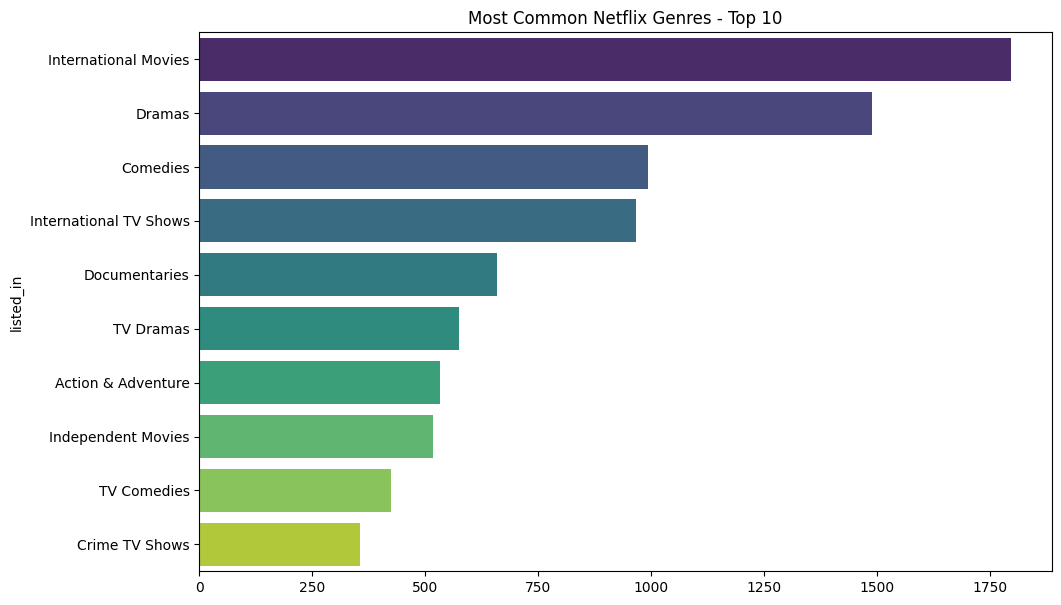

In [ ]:
import warnings
warnings.filterwarnings('ignore')

df_main['listed_in'] = df_main['listed_in'].str.split(',')
gnre = df_main.explode('listed_in')['listed_in'].str.strip().value_counts().head(10)

# Visualizing the top genres
mtplib.figure(figsize=(11, 7))
sebon.barplot(x=gnre.values, y=gnre.index, palette='viridis')
mtplib.title('Most Common Netflix Genres - Top 10')
mtplib.show()

**Answer 1:** *We can see that most of the Netflix Genre belongs to International movies, Dramas and comedy shows/movies. It will help for the proper alignment of content for the audience.*

**Question 2:** Which country has the most Netflix content, What kind of content does the audience like to watch?

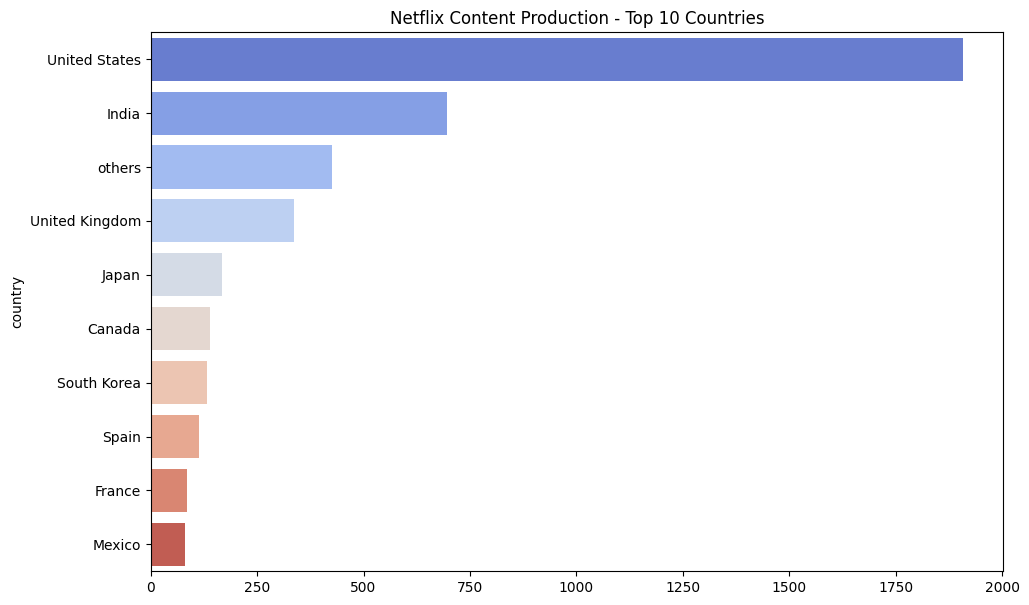

In [ ]:
cntre_counts = df_main['country'].value_counts().head(10)

mtplib.figure(figsize=(11, 7))
sebon.barplot(x=cntre_counts.values, y=cntre_counts.index, palette='coolwarm')
mtplib.title('Netflix Content Production - Top 10 Countries')
mtplib.show()

**Answer 2:** *We can see that most of the Netflix content is from the United States of America and then the contents comes from India. People prefer hollywood content on Netflix and then is Bollywood.*

**Question 3:** In accordance with the content, How can Netflix evolve over the time?

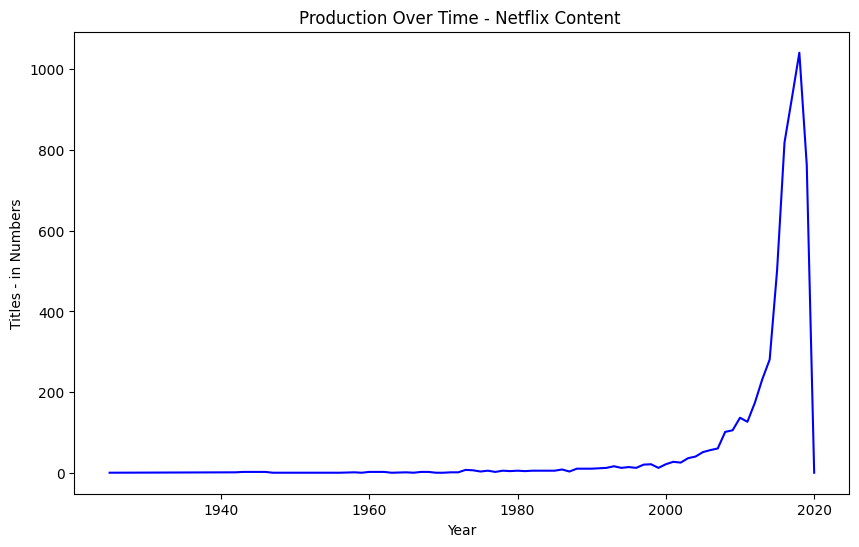

In [ ]:
df_main['release_year'] = pndas.to_datetime(df_main['release_year'], format='%Y', errors='coerce').dt.year
yrly_productn = df_main['release_year'].value_counts().sort_index()

mtplib.figure(figsize=(10, 6))
sebon.lineplot(x=yrly_productn.index, y=yrly_productn.values, color='blue')
mtplib.title('Production Over Time - Netflix Content ')
mtplib.xlabel('Year')
mtplib.ylabel('Titles - in Numbers')
mtplib.show()

**Answer 3:** *By estimating this future predictions can be made on what kind of the content does audience like in accordance with the release date.*

**Question 4:** In accordance with the content which director has the most number of Movies/Tv shows?

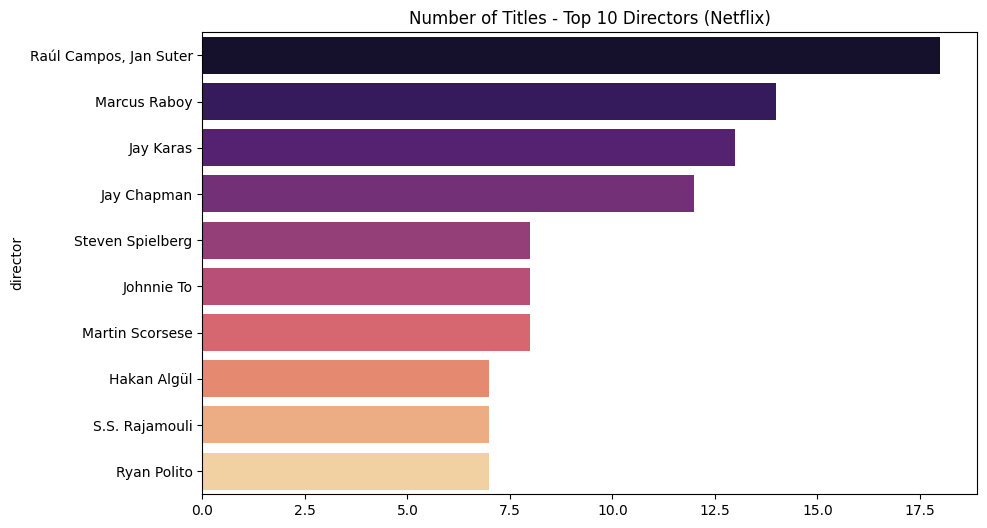

In [ ]:
dftemp = df_main[df_main['director']!="Unknown"]
director_cnts = dftemp['director'].value_counts().head(10)


mtplib.figure(figsize=(10, 6))
sebon.barplot(x=director_cnts.values, y=director_cnts.index, palette='magma')
mtplib.title('Number of Titles - Top 10 Directors (Netflix)')
mtplib.show()

**Answer 4:** *Having this information helps netflix achieve the preferable show's directed by the director in the preference list for the audience.*

**Question 5:** In accordance with the duration how has netflix distributed different titles?

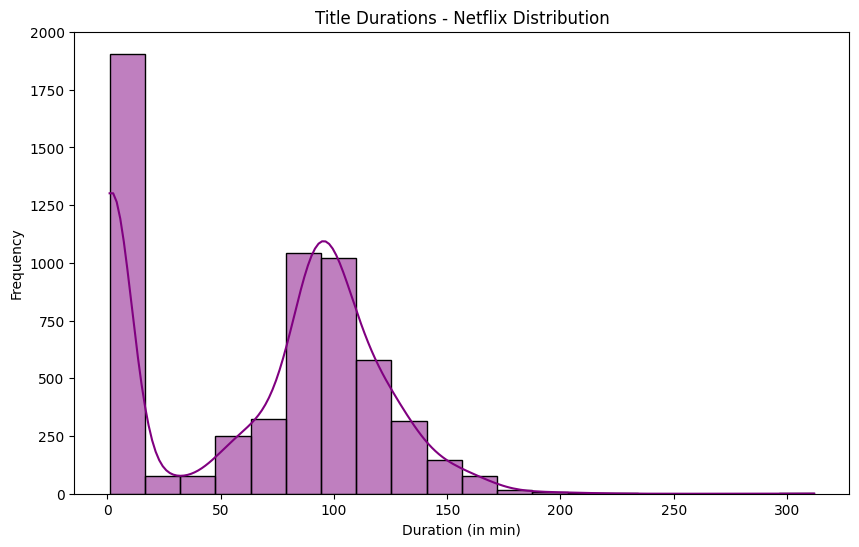

In [ ]:
df_main['duration'] = df_main['duration'].str.extract('(\d+)').astype(float)

mtplib.figure(figsize=(10, 6))
sebon.histplot(df_main['duration'].dropna(), bins=20, kde=True, color='purple')
mtplib.title('Title Durations - Netflix Distribution')
mtplib.xlabel('Duration (in min)')
mtplib.ylabel('Frequency')
mtplib.show()

**Answer 5:** *We can see that most of the content varries for short duration Movies/TV shows. It helps it to distinguish between the audience for what can be shown in the preference watch list for the audience.*

## **Conclusion**

*We can conclude that this dataset has helped us to distinguis between Netflix content in different Nations, what are the most preferred show's/ Movies that the audience like. The duration and release of these movies/shows will help to allign Netflix content for future achievements. Overall it can help to achieve great progress in the coming future.*